# Predict Customer Churn — Exploratory Data Analysis

**Competition:** [Kaggle Playground Series S6E3](https://www.kaggle.com/competitions/playground-series-s6e3/overview)  
**Author:** Denis Lazurenko  
**Role:** Data Analyst — EDA & Feature Engineering  

---

## Objective

Predict which telecom customers are likely to churn (cancel their subscription). This notebook covers the full EDA pipeline: data cleaning, demographic profiling, behavioral analysis, and feature engineering — all grounded in business context.

---

## Table of Contents

1. [Setup & Data Loading](#1-setup--data-loading)
2. [Data Quality Check](#2-data-quality-check)
3. [Demographic Analysis](#3-demographic-analysis)
4. [Behavioral & Financial Analysis](#4-behavioral--financial-analysis)
5. [Service Usage Analysis](#5-service-usage-analysis)
6. [Feature Engineering](#6-feature-engineering)
7. [Key Findings](#7-key-findings)
8. [Appendix — What Could Be Done Next](#8-appendix--what-could-be-done-next)

## 1. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', lambda x: f'{x:.3f}')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
sns.set_style('whitegrid')

RANDOM_STATE = 42
print('Libraries loaded successfully.')

Libraries loaded successfully.


In [2]:
# Update paths as needed
train = pd.read_csv(r'C:\projects\Hackathon\Predict_Customer_Churn\data\raw\train.csv')
test  = pd.read_csv(r'C:\projects\Hackathon\Predict_Customer_Churn\data\raw\test.csv')
sample_submission = pd.read_csv(r'C:\projects\Hackathon\Predict_Customer_Churn\data\raw\sample_submission.csv')

# Work on copies to keep raw data intact
df = train.copy(deep=True)
df_test = test.copy(deep=True)

print(f'Train shape : {train.shape}')
print(f'Test shape  : {test.shape}')

Train shape : (594194, 21)
Test shape  : (254655, 20)


## 2. Data Quality Check

In [3]:
def quick_eda(df):
    """Full dataset diagnostic. Run this first."""
    print('=' * 55)
    print(f'  Shape      : {df.shape[0]:,} rows x {df.shape[1]} columns')
    print(f'  Duplicates : {df.duplicated().sum()}')
    print(f'  Memory     : {df.memory_usage(deep=True).sum() / 1e6:.1f} MB')
    print('=' * 55)

    info = pd.DataFrame({
        'dtype'    : df.dtypes,
        'non-null' : df.count(),
        'missing'  : df.isnull().sum(),
        'missing%' : (df.isnull().mean() * 100).round(2),
        'unique'   : df.nunique()
    })
    return info

quick_eda(df)

  Shape      : 594,194 rows x 21 columns
  Duplicates : 0
  Memory     : 546.2 MB


,dtype,non-null,missing,missing%,unique
id,int64,594194,0,0.000,594194
gender,object,594194,0,0.000,2
SeniorCitizen,int64,594194,0,0.000,2
Partner,object,594194,0,0.000,2
Dependents,object,594194,0,0.000,2
tenure,int64,594194,0,0.000,72
PhoneService,object,594194,0,0.000,2
MultipleLines,object,594194,0,0.000,3
InternetService,object,594194,0,0.000,3
OnlineSecurity,object,594194,0,0.000,3


In [4]:
# TotalCharges contains whitespace strings — convert to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce').fillna(0)

# Verify unique values in key categorical columns
for col in ['InternetService', 'Contract', 'PaymentMethod']:
    print(f'{col}: {df[col].unique()}')

InternetService: ['DSL' 'Fiber optic' 'No']
Contract: ['One year' 'Two year' 'Month-to-month']
PaymentMethod: ['Mailed check' 'Credit card (automatic)' 'Electronic check'
 'Bank transfer (automatic)']


In [5]:
df.sample(5, random_state=RANDOM_STATE)

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
392211,392211,Female,0,Yes,No,71,Yes,Yes,DSL,Yes,Yes,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),89.450,6293.450,No
370260,370260,Female,0,Yes,No,44,Yes,No,DSL,Yes,Yes,Yes,Yes,No,Yes,Two year,No,Mailed check,75.550,3888.600,No
65386,65386,Male,0,Yes,Yes,53,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.750,1077.750,No
526552,526552,Male,0,Yes,Yes,52,Yes,No,DSL,Yes,No,No,Yes,No,No,One year,No,Mailed check,55.200,2719.200,No
3996,3996,Male,0,No,No,1,Yes,No,DSL,No,No,No,No,No,No,Month-to-month,No,Mailed check,44.700,44.700,Yes


### Target Distribution

The dataset is imbalanced — approximately 22.5% of customers churned. This will need to be addressed in modeling.

In [6]:
# Step 1 — calculate
churn_counts = df['Churn'].value_counts()
churn_rate   = df['Churn'].value_counts(normalize=True) * 100

print('Churn distribution:')
print(f'  Stayed  : {churn_counts["No"]:,}  ({churn_rate["No"]:.1f}%)')
print(f'  Churned : {churn_counts["Yes"]:,}  ({churn_rate["Yes"]:.1f}%)')
print(f'  Imbalance ratio: 1 churned for every {churn_rate["No"]/churn_rate["Yes"]:.1f} retained')

Churn distribution:
  Stayed  : 460,377  (77.5%)
  Churned : 133,817  (22.5%)
  Imbalance ratio: 1 churned for every 3.4 retained


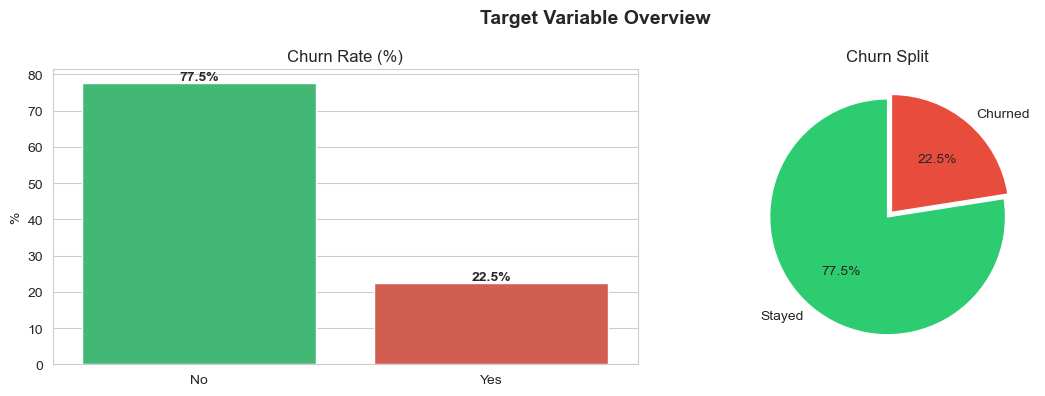

In [7]:
# Step 2 — visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.barplot(x=churn_rate.index, y=churn_rate.values,
            palette=['#2ecc71', '#e74c3c'], ax=axes[0])
axes[0].set_title('Churn Rate (%)')
axes[0].set_xlabel('')
axes[0].set_ylabel('%')
for p in axes[0].patches:
    axes[0].annotate(f'{p.get_height():.1f}%',
                     (p.get_x() + p.get_width() / 2, p.get_height()),
                     ha='center', va='bottom', fontweight='bold')

axes[1].pie(churn_rate.values, labels=['Stayed', 'Churned'],
            autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'],
            startangle=90, explode=[0, 0.05])
axes[1].set_title('Churn Split')

plt.suptitle('Target Variable Overview', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Demographic Analysis

### 3.1 Senior Citizens — The High-Risk Segment

In [8]:
# Step 1 — calculate
senior_nat = df.loc[df['SeniorCitizen'] == 1]
other_nat  = df.loc[df['SeniorCitizen'] == 0]

senior_count   = len(senior_nat)
other_count    = len(other_nat)
senior_pct     = senior_count / len(df) * 100

senior_avg_charges  = senior_nat['TotalCharges'].mean()
other_avg_charges   = other_nat['TotalCharges'].mean()

senior_revenue_pct  = senior_nat['TotalCharges'].sum() / df['TotalCharges'].sum() * 100

senior_median_tenure = senior_nat['tenure'].median()
other_median_tenure  = other_nat['tenure'].median()

print('--- Senior Citizens Overview ---')
print(f'  Count         : {senior_count:,} ({senior_pct:.1f}% of all customers)')
print(f'  Revenue share : {senior_revenue_pct:.1f}% of total revenue')
print(f'  Avg charges   : ${senior_avg_charges:,.0f} (younger: ${other_avg_charges:,.0f})')
print(f'  Median tenure : {senior_median_tenure:.0f} months (younger: {other_median_tenure:.0f} months)')

--- Senior Citizens Overview ---
  Count         : 67,799 (11.4% of all customers)
  Revenue share : 12.7% of total revenue
  Avg charges   : $2,775 (younger: $2,458)
  Median tenure : 25 months (younger: 37 months)


In [9]:
# Churn rates — the key numbers
senior_churn_pct = (df.loc[(df['Churn'] == 'Yes') & (df['SeniorCitizen'] == 1)].shape[0] * 100) / \
                    df.loc[df['SeniorCitizen'] == 1].shape[0]

other_churn_pct  = (df.loc[(df['Churn'] == 'Yes') & (df['SeniorCitizen'] == 0)].shape[0] * 100) / \
                    df.loc[df['SeniorCitizen'] == 0].shape[0]

overall_churn_pct = (df['Churn'] == 'Yes').mean() * 100

print('--- Churn Rate by Segment ---')
print(f'  Senior  : {senior_churn_pct:.1f}%')
print(f'  Younger : {other_churn_pct:.1f}%')
print(f'  Overall : {overall_churn_pct:.1f}%')
print(f'  Seniors churn {senior_churn_pct / other_churn_pct:.1f}x more often than younger customers.')

--- Churn Rate by Segment ---
  Senior  : 50.0%
  Younger : 19.0%
  Overall : 22.5%
  Seniors churn 2.6x more often than younger customers.


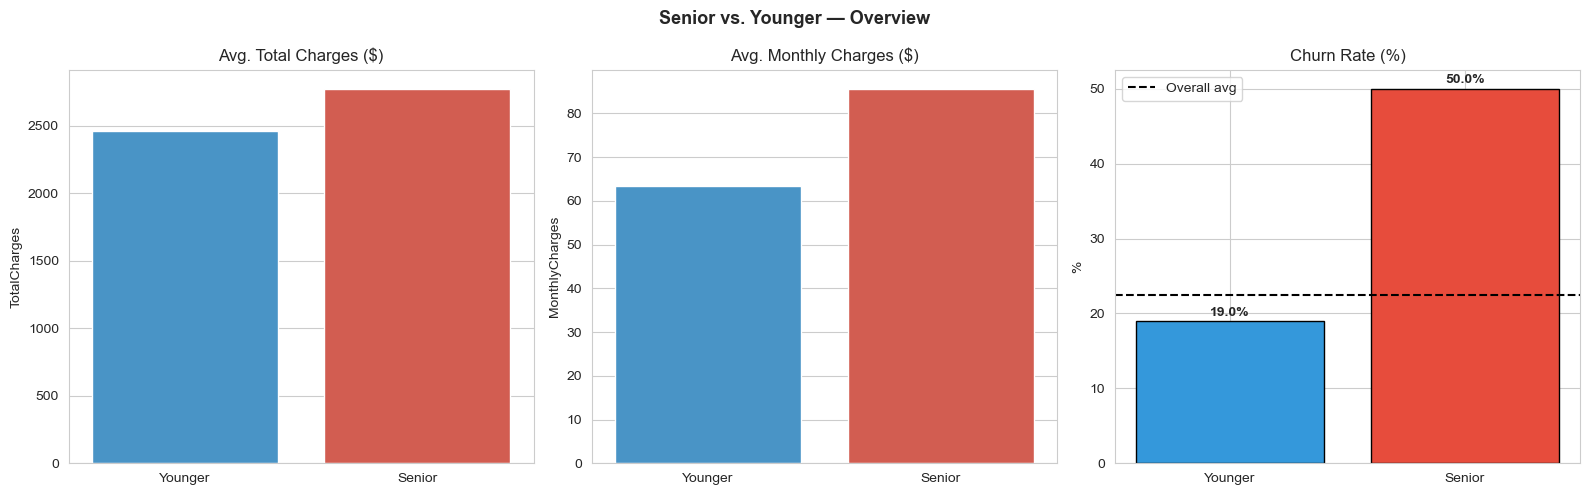

In [10]:
# Step 2 — visualize
df['Segment'] = df['SeniorCitizen'].map({0: 'Younger', 1: 'Senior'})
df['Churn_bin'] = (df['Churn'] == 'Yes').astype(int)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sns.barplot(data=df, x='Segment', y='TotalCharges',
            palette=['#3498db', '#e74c3c'], errorbar=None, ax=axes[0])
axes[0].set_title('Avg. Total Charges ($)')
axes[0].set_xlabel('')

sns.barplot(data=df, x='Segment', y='MonthlyCharges',
            palette=['#3498db', '#e74c3c'], errorbar=None, ax=axes[1])
axes[1].set_title('Avg. Monthly Charges ($)')
axes[1].set_xlabel('')

segments   = ['Younger', 'Senior']
churn_vals = [other_churn_pct, senior_churn_pct]
bars = axes[2].bar(segments, churn_vals, color=['#3498db', '#e74c3c'], edgecolor='black')
axes[2].axhline(y=overall_churn_pct, color='black', linestyle='--', linewidth=1.5, label='Overall avg')
axes[2].set_title('Churn Rate (%)')
axes[2].set_ylabel('%')
axes[2].legend()
for bar, val in zip(bars, churn_vals):
    axes[2].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
                 f'{val:.1f}%', ha='center', va='bottom', fontweight='bold')

plt.suptitle('Senior vs. Younger — Overview', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

> **Finding:** Seniors represent 11% of the customer base but contribute 13% of revenue — and churn at 2.6x the rate of younger customers.

### 3.2 Gender — Does It Matter?

In [11]:
# Step 1 — calculate
senior_gender_churn = df[df['SeniorCitizen'] == 1].groupby(['gender', 'Churn']).size().unstack()
senior_gender_churn_pct = senior_gender_churn.div(senior_gender_churn.sum(axis=1), axis=0) * 100

other_gender_churn = df[df['SeniorCitizen'] == 0].groupby(['gender', 'Churn']).size().unstack()
other_gender_churn_pct = other_gender_churn.div(other_gender_churn.sum(axis=1), axis=0) * 100

print('Churn rate by gender — Seniors:')
print(senior_gender_churn_pct['Yes'].round(1).to_string())
print('\nChurn rate by gender — Younger:')
print(other_gender_churn_pct['Yes'].round(1).to_string())

Churn rate by gender — Seniors:
gender
Female   50.300
Male     49.800

Churn rate by gender — Younger:
gender
Female   19.300
Male     18.700


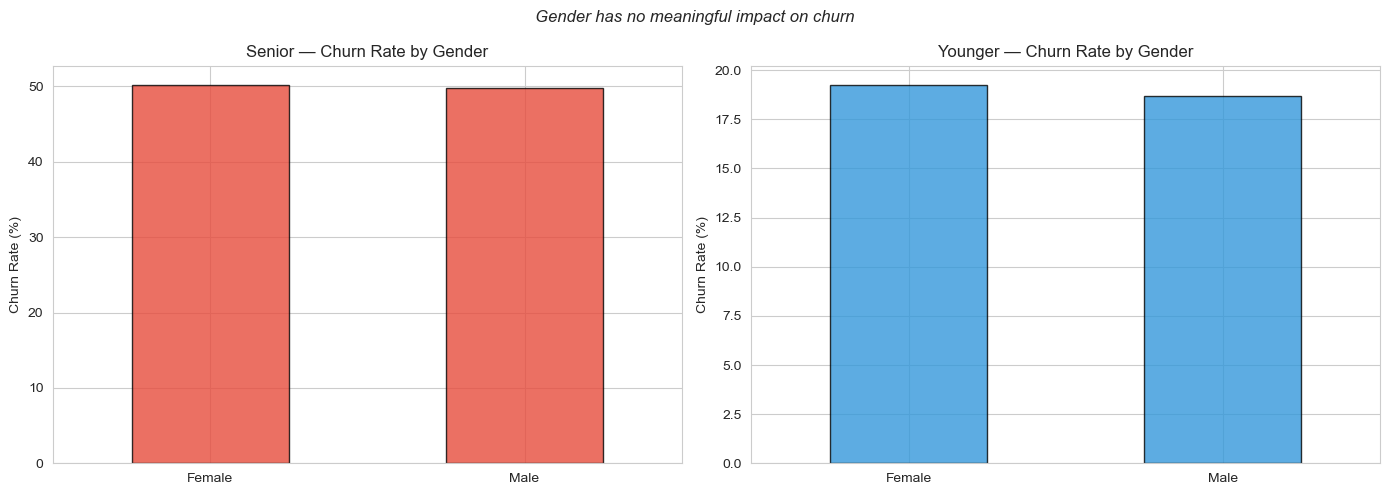

In [12]:
# Step 2 — visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

senior_gender_churn_pct['Yes'].plot(
    kind='bar', ax=axes[0], color=['#e74c3c', '#e74c3c'], edgecolor='black', alpha=0.8)
axes[0].set_title('Senior — Churn Rate by Gender')
axes[0].set_ylabel('Churn Rate (%)')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=0)

other_gender_churn_pct['Yes'].plot(
    kind='bar', ax=axes[1], color=['#3498db', '#3498db'], edgecolor='black', alpha=0.8)
axes[1].set_title('Younger — Churn Rate by Gender')
axes[1].set_ylabel('Churn Rate (%)')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=0)

plt.suptitle('Gender has no meaningful impact on churn', fontsize=12, style='italic')
plt.tight_layout()
plt.show()

> **Finding:** Gender is evenly split (~50/50) and shows no meaningful churn difference in either segment. It will not be a useful predictive feature.

### 3.3 Family Status — The Retention Anchor

In [13]:
# Step 1 — calculate
senior_churn_by_dep = df[df['SeniorCitizen'] == 1].groupby(['Dependents', 'Churn']).size().unstack()
senior_churn_by_dep_pct = senior_churn_by_dep.div(senior_churn_by_dep.sum(axis=1), axis=0) * 100

other_churn_by_dep = df[df['SeniorCitizen'] == 0].groupby(['Dependents', 'Churn']).size().unstack()
other_churn_by_dep_pct = other_churn_by_dep.div(other_churn_by_dep.sum(axis=1), axis=0) * 100

print('Senior — churn rate by Dependents:')
print(senior_churn_by_dep_pct['Yes'].round(1).to_string())
print('\nYounger — churn rate by Dependents:')
print(other_churn_by_dep_pct['Yes'].round(1).to_string())

Senior — churn rate by Dependents:
Dependents
No    50.800
Yes   22.500

Younger — churn rate by Dependents:
Dependents
No    25.000
Yes    7.100


In [14]:
# Family level composite score
def get_family_level(row):
    score = 0
    if row['Partner'] == 'Yes': score += 1
    if row['Dependents'] == 'Yes': score += 1
    return score

df['family_level'] = df.apply(get_family_level, axis=1)

family_churn = pd.crosstab(df['family_level'], df['Churn'], normalize='index') * 100
family_churn.index = ['Alone (0)', 'Partner or Kids (1)', 'Full Family (2)']

print('Churn rate by family level:')
print(family_churn['Yes'].round(1).to_string())
print(f'\nDifference: alone vs full family = {family_churn["Yes"].iloc[0] - family_churn["Yes"].iloc[2]:.1f} pp')

Churn rate by family level:
Alone (0)             33.300
Partner or Kids (1)   20.800
Full Family (2)        6.600

Difference: alone vs full family = 26.7 pp


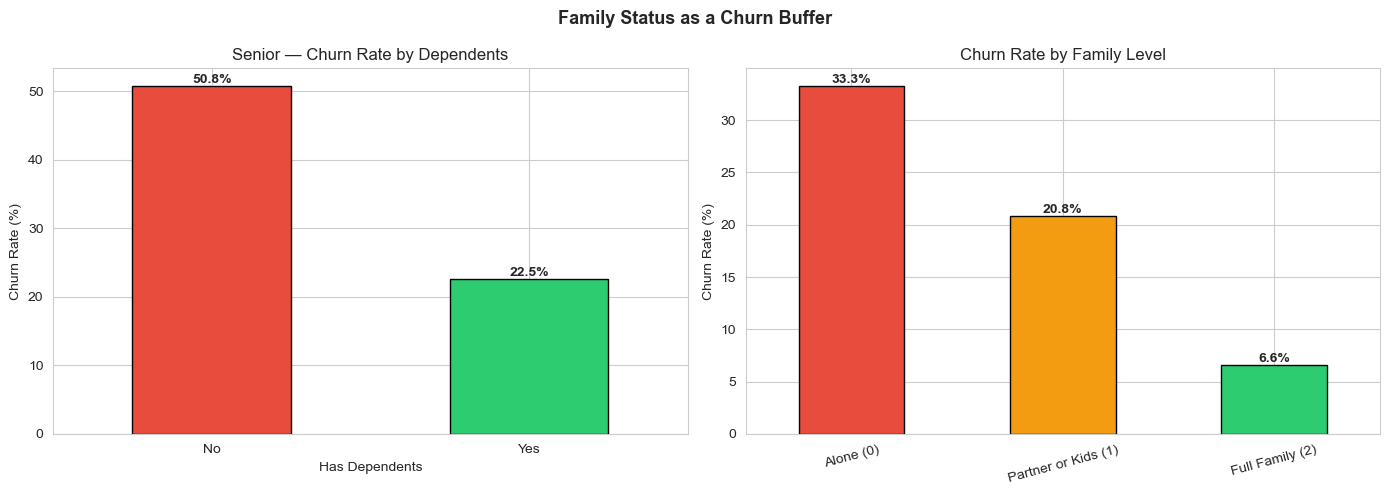

In [15]:
# Step 2 — visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

senior_churn_by_dep_pct['Yes'].plot(
    kind='bar', ax=axes[0], color=['#e74c3c', '#2ecc71'], edgecolor='black')
axes[0].set_title('Senior — Churn Rate by Dependents')
axes[0].set_ylabel('Churn Rate (%)')
axes[0].set_xlabel('Has Dependents')
axes[0].tick_params(axis='x', rotation=0)
for p in axes[0].patches:
    axes[0].annotate(f'{p.get_height():.1f}%',
                     (p.get_x() + p.get_width() / 2, p.get_height()),
                     ha='center', va='bottom', fontweight='bold')

family_churn['Yes'].plot(
    kind='bar', ax=axes[1], color=['#e74c3c', '#f39c12', '#2ecc71'], edgecolor='black')
axes[1].set_title('Churn Rate by Family Level')
axes[1].set_ylabel('Churn Rate (%)')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=15)
for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height():.1f}%',
                     (p.get_x() + p.get_width() / 2, p.get_height()),
                     ha='center', va='bottom', fontweight='bold')

plt.suptitle('Family Status as a Churn Buffer', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Behavioral & Financial Analysis

### 4.1 Tenure — The Critical First Year

In [16]:
# Step 1 — calculate
def tenure_group(t):
    if t <= 12:   return '0-1 year'
    elif t <= 24: return '1-2 years'
    elif t <= 48: return '2-4 years'
    else:         return '4+ years'

df['tenure_group'] = df['tenure'].apply(tenure_group)

tenure_churn = df.groupby('tenure_group')['Churn'].value_counts(normalize=True).unstack() * 100
order = ['0-1 year', '1-2 years', '2-4 years', '4+ years']
tenure_churn = tenure_churn.reindex(order)

senior_median_tenure = senior_nat['tenure'].median()
other_median_tenure  = other_nat['tenure'].median()

print('Churn rate by tenure group:')
print(tenure_churn['Yes'].round(1).to_string())
print(f'\nMedian tenure — Senior: {senior_median_tenure:.0f} months | Younger: {other_median_tenure:.0f} months')

Churn rate by tenure group:
tenure_group
0-1 year    49.400
1-2 years   28.600
2-4 years   17.100
4+ years     5.300

Median tenure — Senior: 25 months | Younger: 37 months


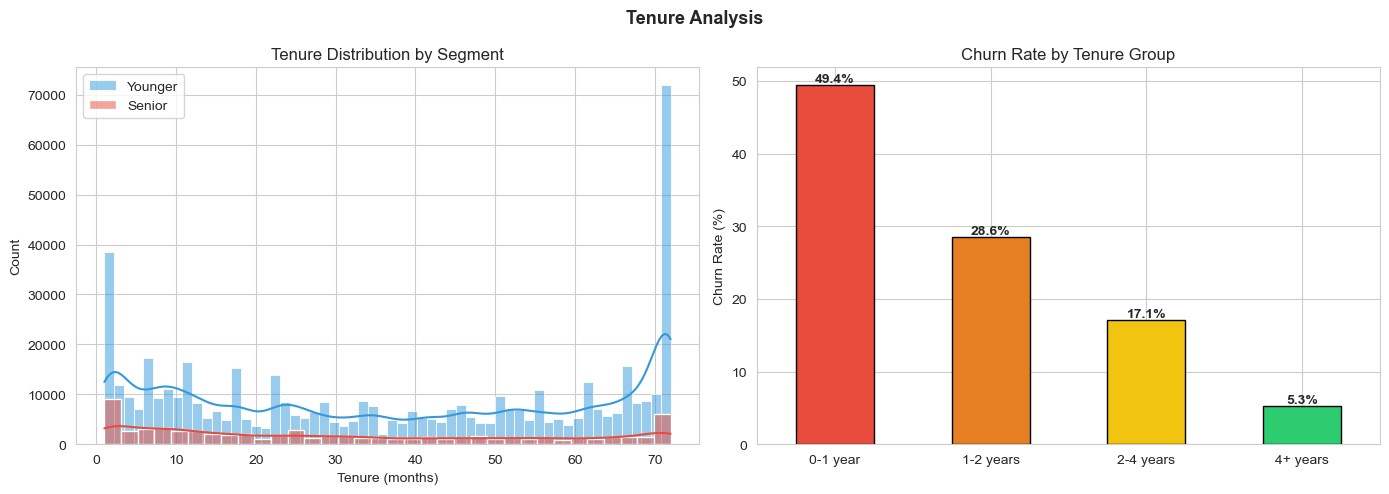

In [17]:
# Step 2 — visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(other_nat['tenure'], color='#3498db', label='Younger', kde=True, ax=axes[0])
sns.histplot(senior_nat['tenure'], color='#e74c3c', label='Senior', kde=True, ax=axes[0])
axes[0].set_title('Tenure Distribution by Segment')
axes[0].set_xlabel('Tenure (months)')
axes[0].legend()

tenure_churn['Yes'].plot(
    kind='bar', ax=axes[1],
    color=['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71'], edgecolor='black')
axes[1].set_title('Churn Rate by Tenure Group')
axes[1].set_ylabel('Churn Rate (%)')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=0)
for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height():.1f}%',
                     (p.get_x() + p.get_width() / 2, p.get_height()),
                     ha='center', va='bottom', fontweight='bold')

plt.suptitle('Tenure Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

> **Finding:** The first 12 months are the "death zone" — highest churn risk. Surviving past 12 months makes loyalty significantly more stable.

### 4.2 Monthly Charges — The Price Signal

In [18]:
# Step 1 — calculate
charges_by_churn = df.groupby('Churn')['MonthlyCharges'].mean()
charges_by_segment_churn = df.groupby(['SeniorCitizen', 'Churn'])['MonthlyCharges'].mean().unstack()
charges_by_segment_churn.index = ['Younger', 'Senior']

print('Average monthly charges by churn status:')
print(f'  Stayed  : ${charges_by_churn["No"]:.2f}')
print(f'  Churned : ${charges_by_churn["Yes"]:.2f}')
print('\nAverage monthly charges by segment and churn:')
print(charges_by_segment_churn.round(2).to_string())

Average monthly charges by churn status:
  Stayed  : $61.29
  Churned : $81.60

Average monthly charges by segment and churn:
Churn       No    Yes
Younger 59.410 79.970
Senior  85.000 86.400


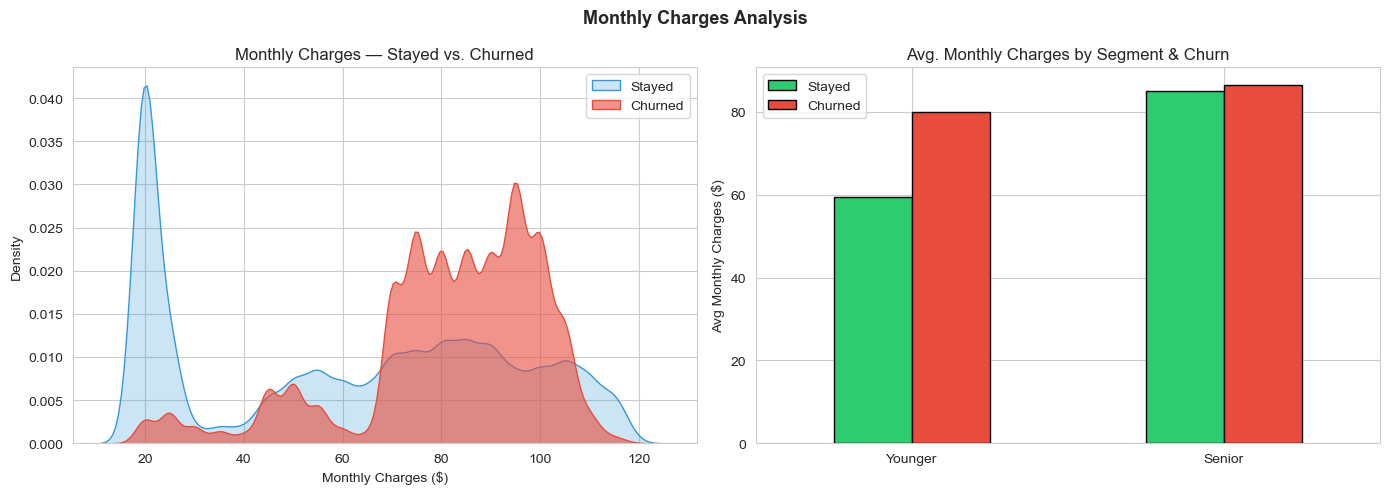

In [19]:
# Step 2 — visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.kdeplot(df[df['Churn'] == 'No']['MonthlyCharges'],
            label='Stayed', fill=True, color='#3498db', ax=axes[0])
sns.kdeplot(df[df['Churn'] == 'Yes']['MonthlyCharges'],
            label='Churned', fill=True, color='#e74c3c', alpha=0.6, ax=axes[0])
axes[0].set_title('Monthly Charges — Stayed vs. Churned')
axes[0].set_xlabel('Monthly Charges ($)')
axes[0].legend()

charges_by_segment_churn.plot(kind='bar', ax=axes[1],
                               color=['#2ecc71', '#e74c3c'], edgecolor='black')
axes[1].set_title('Avg. Monthly Charges by Segment & Churn')
axes[1].set_xlabel('')
axes[1].set_ylabel('Avg Monthly Charges ($)')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(['Stayed', 'Churned'])

plt.suptitle('Monthly Charges Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 4.3 Contract Type & Payment Method

In [20]:
# Step 1 — calculate
def get_churn_report(dataframe, column):
    """Returns churn rate breakdown for a given column."""
    return dataframe.groupby(column)['Churn'].value_counts(normalize=True).unstack() * 100

for col in ['Contract', 'PaymentMethod', 'PaperlessBilling']:
    report = get_churn_report(df, col)
    print(f'\nChurn rate by {col}:')
    print(report['Yes'].sort_values(ascending=False).round(1).to_string())


Churn rate by Contract:
Contract
Month-to-month   42.100
One year          5.800
Two year          1.000

Churn rate by PaymentMethod:
PaymentMethod
Electronic check            48.900
Mailed check                 8.000
Bank transfer (automatic)    7.700
Credit card (automatic)      6.900

Churn rate by PaperlessBilling:
PaperlessBilling
Yes   31.900
No     7.500


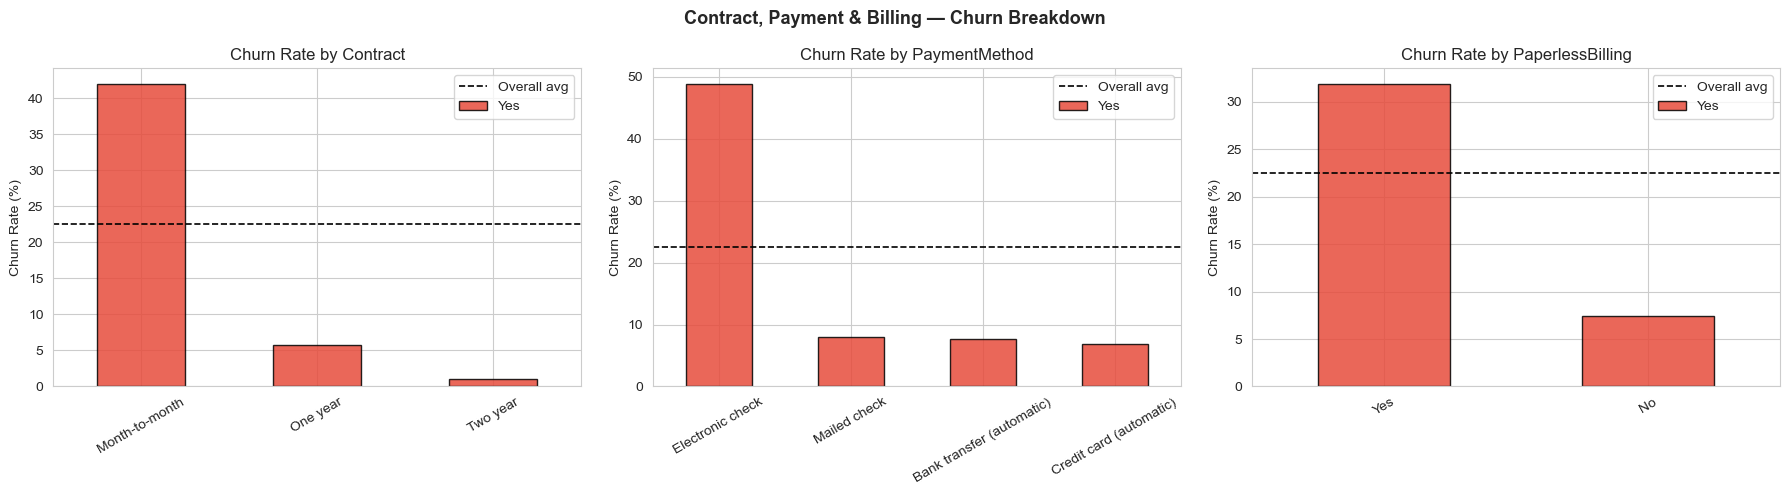

In [21]:
# Step 2 — visualize
cols_to_check = ['Contract', 'PaymentMethod', 'PaperlessBilling']
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col in zip(axes, cols_to_check):
    report = get_churn_report(df, col)['Yes'].sort_values(ascending=False)
    report.plot(kind='bar', ax=ax, color='#e74c3c', edgecolor='black', alpha=0.85)
    ax.set_title(f'Churn Rate by {col}')
    ax.set_xlabel('')
    ax.set_ylabel('Churn Rate (%)')
    ax.tick_params(axis='x', rotation=30)
    ax.axhline(y=overall_churn_pct, color='black', linestyle='--',
               linewidth=1.2, label='Overall avg')
    ax.legend()

plt.suptitle('Contract, Payment & Billing — Churn Breakdown',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 4.4 The Fiber Optic Trap

In [22]:
# Step 1 — calculate
fiber_senior_pct = (senior_nat['InternetService'] == 'Fiber optic').mean() * 100
fiber_other_pct  = (other_nat['InternetService'] == 'Fiber optic').mean() * 100

fiber_churn = get_churn_report(df, 'InternetService')

print(f'Fiber Optic adoption:')
print(f'  Seniors : {fiber_senior_pct:.1f}%')
print(f'  Younger : {fiber_other_pct:.1f}%')
print(f'\nChurn rate by internet service:')
print(fiber_churn['Yes'].sort_values(ascending=False).round(1).to_string())

Fiber Optic adoption:
  Seniors : 85.5%
  Younger : 40.7%

Churn rate by internet service:
InternetService
Fiber optic   41.500
DSL           10.300
No             1.400


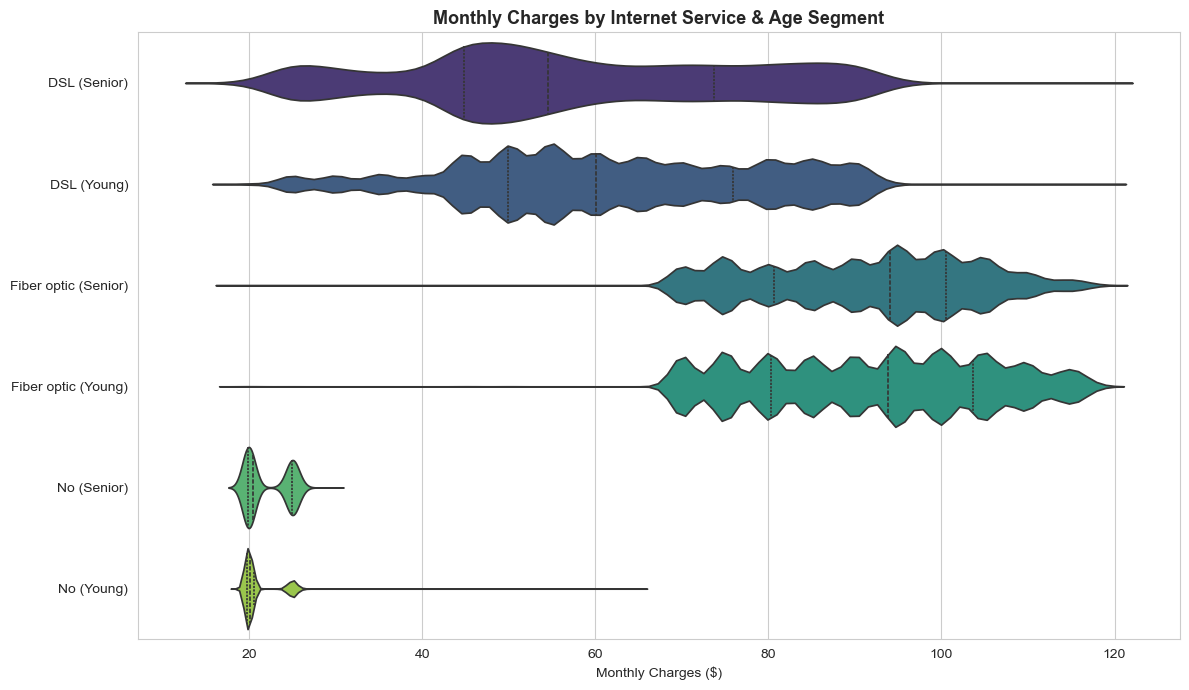

In [23]:
# Step 2 — visualize
df_plot = df.copy()
df_plot['Group'] = df_plot['InternetService'] + ' (' + \
                   df_plot['SeniorCitizen'].map({1: 'Senior', 0: 'Young'}) + ')'
order = sorted(df_plot['Group'].unique())

plt.figure(figsize=(12, 7))
sns.violinplot(data=df_plot, y='Group', x='MonthlyCharges',
               order=order, palette='viridis', inner='quartile')
plt.title('Monthly Charges by Internet Service & Age Segment',
          fontsize=13, fontweight='bold')
plt.xlabel('Monthly Charges ($)')
plt.ylabel('')
plt.tight_layout()
plt.show()

## 5. Service Usage Analysis

In [24]:
# Step 1 — calculate
services = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
            'TechSupport', 'StreamingTV', 'StreamingMovies']
df['services_count'] = (df[services] == 'Yes').sum(axis=1)

avg_services_by_segment = df.groupby('SeniorCitizen')['services_count'].mean()
avg_services_by_segment.index = ['Younger', 'Senior']

print('Average number of add-on services per segment:')
print(avg_services_by_segment.round(2).to_string())

Average number of add-on services per segment:
Younger   2.020
Senior    2.300


In [25]:
# Service adoption rate per segment
comparison = []
for s in services:
    for status in [0, 1]:
        label = 'Senior' if status == 1 else 'Younger'
        pct = (df[df['SeniorCitizen'] == status][s] == 'Yes').mean() * 100
        comparison.append({'Service': s, 'Segment': label, 'Adoption (%)': pct})

comp_df = pd.DataFrame(comparison)

print('\nService adoption by segment (%):')
print(comp_df.pivot(index='Service', columns='Segment', values='Adoption (%)').round(1).to_string())


Service adoption by segment (%):
Segment           Senior  Younger
Service                          
DeviceProtection  39.600   34.100
OnlineBackup      37.500   33.800
OnlineSecurity    17.900   28.900
StreamingMovies   58.600   38.300
StreamingTV       58.500   38.100
TechSupport       17.600   29.100


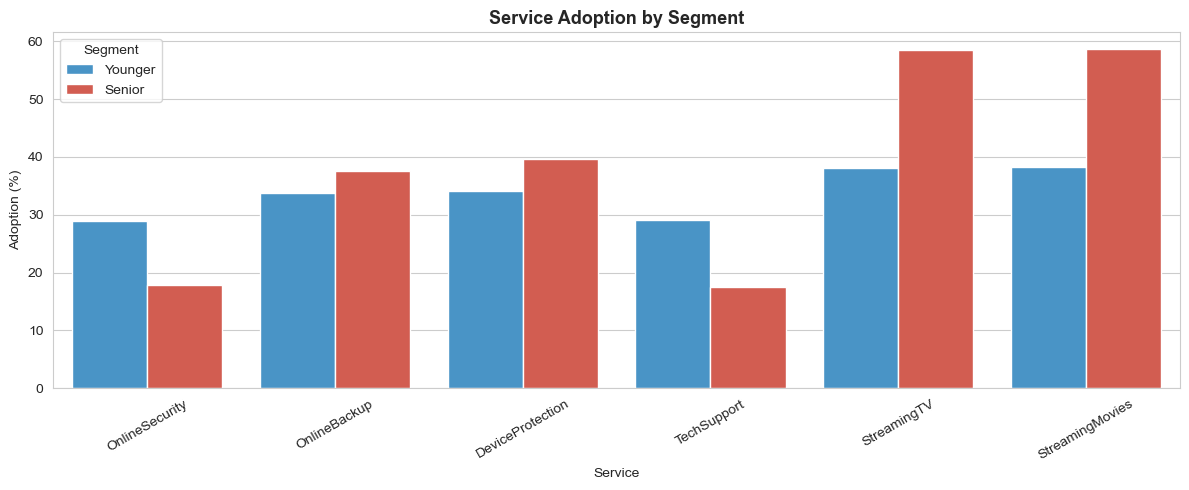

In [26]:
# Step 2 — visualize
plt.figure(figsize=(12, 5))
sns.barplot(data=comp_df, x='Service', y='Adoption (%)',
            hue='Segment', palette={'Younger': '#3498db', 'Senior': '#e74c3c'})
plt.title('Service Adoption by Segment', fontsize=13, fontweight='bold')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [27]:
# Correlation matrix
df['price_per_service'] = df['MonthlyCharges'] / (df['services_count'] + 1)

numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges',
                'services_count', 'price_per_service']
corr_matrix = df[numeric_cols].corr()

# Calculate correlation with churn for reference
df['Churn_bin'] = (df['Churn'] == 'Yes').astype(int)
corr_with_churn = df[numeric_cols + ['Churn_bin']].corr()['Churn_bin'].drop('Churn_bin').sort_values()

print('Correlation with Churn (linear):')
print(corr_with_churn.round(3).to_string())

formula_corr = (df['tenure'] * df['MonthlyCharges']).corr(df['TotalCharges'])
print(f'\nCorrelation (tenure × MonthlyCharges) vs TotalCharges: {formula_corr:.4f}')
print('TotalCharges is near-redundant — dropping it in modeling.')

Correlation with Churn (linear):
tenure              -0.418
TotalCharges        -0.218
services_count      -0.074
MonthlyCharges       0.273
price_per_service    0.349

Correlation (tenure × MonthlyCharges) vs TotalCharges: 0.9921
TotalCharges is near-redundant — dropping it in modeling.


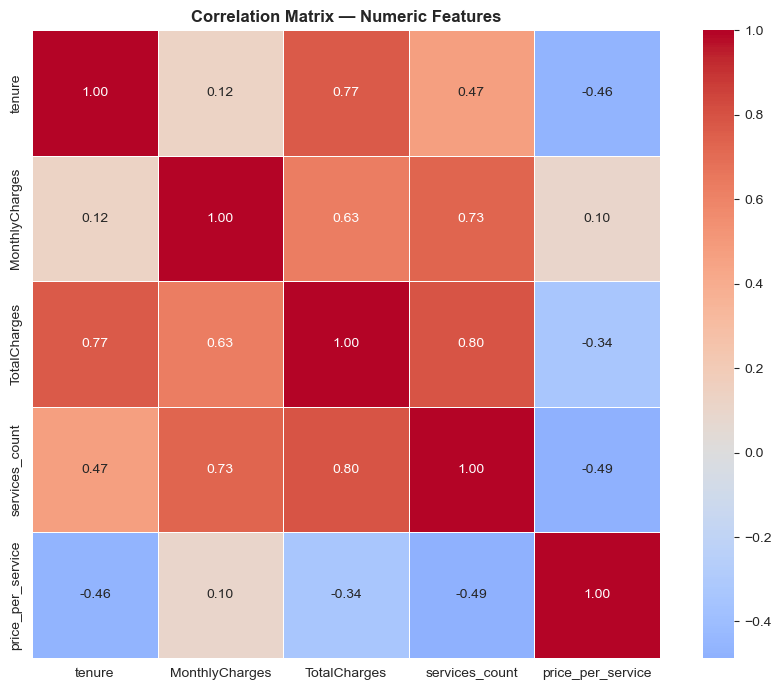

In [28]:
# Step 2 — visualize
plt.figure(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0,
            fmt='.2f', square=True, linewidths=0.5)
plt.title('Correlation Matrix — Numeric Features', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Feature Engineering

Based on the EDA insights above, the following features encode domain knowledge into the model.

In [29]:
ml_ready = df.copy()

# 1. Technical risk: Fiber Optic without tech support
ml_ready['no_help_fiber'] = ((ml_ready['InternetService'] == 'Fiber optic') &
                              (ml_ready['TechSupport'] == 'No')).astype(int)

# 2. Financial risk trigger: Senior + Electronic check + Month-to-month
ml_ready['senior_churn_trigger'] = ((ml_ready['SeniorCitizen'] == 1) &
                                     (ml_ready['PaymentMethod'] == 'Electronic check') &
                                     (ml_ready['Contract'] == 'Month-to-month')).astype(int)

# 3. Auto-payment flag
ml_ready['is_auto_pay'] = ml_ready['PaymentMethod'].str.contains('automatic').astype(int)

# 4. Price per service
ml_ready['price_per_service'] = ml_ready['MonthlyCharges'] / (ml_ready['services_count'] + 1)

# 5. Family level
ml_ready['family_level'] = (ml_ready['Partner'] == 'Yes').astype(int) + \
                            (ml_ready['Dependents'] == 'Yes').astype(int)

# Check feature distributions
new_features = ['no_help_fiber', 'senior_churn_trigger', 'is_auto_pay',
                'price_per_service', 'family_level']

print('--- New features summary ---')
print(ml_ready[new_features].describe().round(2).to_string())

# Quick churn rate check for binary features
for feat in ['no_help_fiber', 'senior_churn_trigger', 'is_auto_pay']:
    churn_with    = (ml_ready[ml_ready[feat] == 1]['Churn'] == 'Yes').mean() * 100
    churn_without = (ml_ready[ml_ready[feat] == 0]['Churn'] == 'Yes').mean() * 100
    print(f'\n{feat}: churn with=1: {churn_with:.1f}% | with=0: {churn_without:.1f}%')

--- New features summary ---
       no_help_fiber  senior_churn_trigger  is_auto_pay  price_per_service  family_level
count     594194.000            594194.000   594194.000         594194.000    594194.000
mean           0.350                 0.070        0.430             26.320         0.820
std            0.480                 0.260        0.490             15.140         0.840
min            0.000                 0.000        0.000              4.020         0.000
25%            0.000                 0.000        0.000             18.230         0.000
50%            0.000                 0.000        0.000             20.650         1.000
75%            1.000                 0.000        1.000             28.270         2.000
max            1.000                 1.000        1.000             93.700         2.000

no_help_fiber: churn with=1: 48.9% | with=0: 8.5%

senior_churn_trigger: churn with=1: 67.0% | with=0: 19.1%

is_auto_pay: churn with=1: 7.3% | with=0: 34.0%


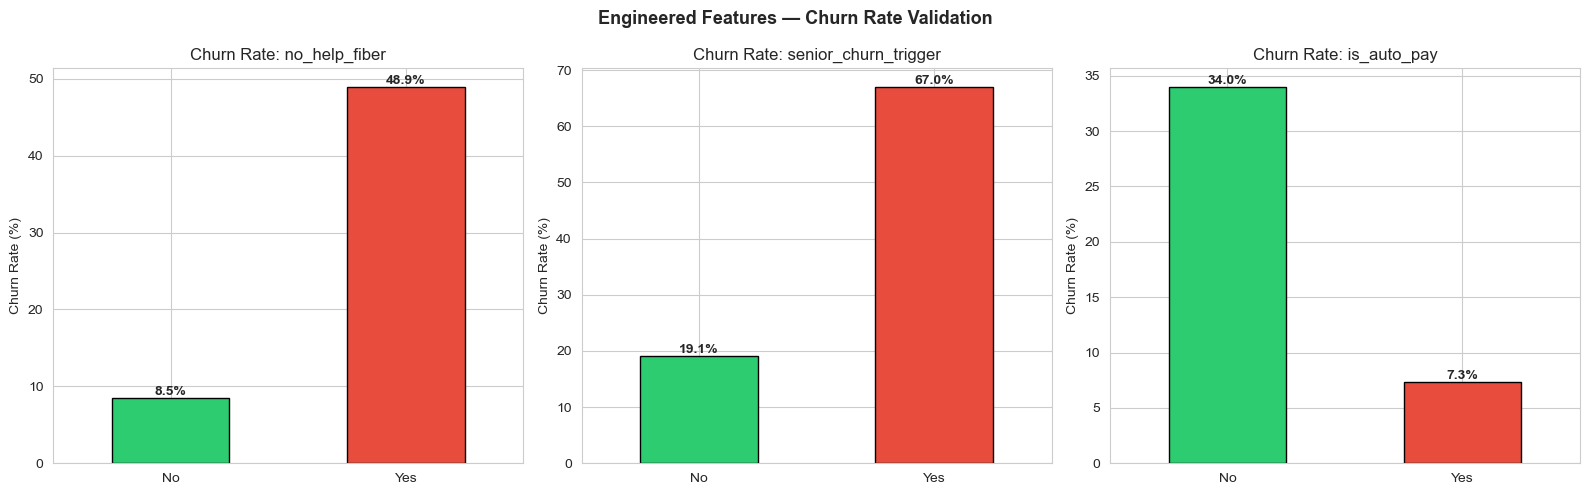

In [30]:
# Visualize: churn rate for each engineered feature
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
binary_features = ['no_help_fiber', 'senior_churn_trigger', 'is_auto_pay']

for ax, feat in zip(axes, binary_features):
    churn_by_feat = ml_ready.groupby(feat)['Churn_bin'].mean() * 100
    churn_by_feat.index = ['No', 'Yes']
    churn_by_feat.plot(kind='bar', ax=ax,
                       color=['#2ecc71', '#e74c3c'], edgecolor='black')
    ax.set_title(f'Churn Rate: {feat}')
    ax.set_ylabel('Churn Rate (%)')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=0)
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.1f}%',
                    (p.get_x() + p.get_width() / 2, p.get_height()),
                    ha='center', va='bottom', fontweight='bold')

plt.suptitle('Engineered Features — Churn Rate Validation',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Key Findings

### Socio-Demographic

| Finding | Detail |
|---|---|
| **Senior churn rate is 2.6x higher** | 50% vs. 19% for younger customers |
| **Family as a retention anchor** | Customers with partner + dependents churn ~5x less |
| **Lone seniors are highest-risk** | 60%+ churn rate without dependents |
| **Gender is irrelevant** | No meaningful difference across either segment |

### Financial & Contractual

| Finding | Detail |
|---|---|
| **Month-to-month = primary driver** | 61% churn vs. <5% on 2-year contracts |
| **Electronic check correlates with churn** | Manual payment friction signal |
| **`price_per_service` reveals dissatisfaction** | High spend relative to services received |
| **Paperless billing paradox** | Higher churn despite digital preference |

### Technical & Behavioral

| Finding | Detail |
|---|---|
| **Fiber Optic trap** | High price, most seniors lack tech support |
| **DSL = stability** | Slower internet, lower churn, more predictable profiles |
| **First 12 months are critical** | Majority of churn happens in the "death zone" |
| **Tenure is the strongest signal** | Long-term customers almost never leave |

### Engineered Features — Validated by Permutation Importance

| Feature | Importance | Rationale |
|---|---|---|
| `price_per_service` | **0.103** | Captures hidden price dissatisfaction |
| `no_help_fiber` | Top-15 | Technical risk indicator |
| `family_level` | 0.007 | Social stability proxy |
| `senior_churn_trigger` | 0.005 | Composite high-risk flag |

## 8. Appendix — What Could Be Done Next

---

### A. Additional EDA Techniques

**Survival Analysis (Kaplan-Meier)**  
Treat churn as a time-to-event problem. Model *when* a customer is likely to churn given their tenure.

```python
# from lifelines import KaplanMeierFitter
# kmf = KaplanMeierFitter()
# kmf.fit(df['tenure'], event_observed=(df['Churn'] == 'Yes'))
# kmf.plot_survival_function()
```

**SHAP Values for Explainability**  
Explain individual predictions — *why* is this specific customer predicted to churn?

```python
# import shap
# explainer = shap.TreeExplainer(model)
# shap_values = explainer.shap_values(X_test)
# shap.summary_plot(shap_values, X_test)
```

**Customer Segmentation (Clustering)**  
Use K-Means on numeric features to find natural customer clusters with distinct churn profiles.

---

### B. Advanced Feature Engineering

**N-gram Categorical Interactions**  
Combine top categorical features into bi-grams. For example, `Contract + InternetService` captures interaction effects that single features miss.

```python
# from itertools import combinations
# for c1, c2 in combinations(['Contract', 'InternetService', 'PaymentMethod'], 2):
#     df[f'BG_{c1}_{c2}'] = df[c1].astype(str) + '_' + df[c2].astype(str)
```

**Target Encoding with OOF**  
Replace category labels with mean churn rate — computed inside cross-validation folds to prevent data leakage.

---

### C. Modeling Improvements

**OOF Stacking** — train a meta-model on out-of-fold predictions from base models  
**Neural Network (MLP)** — captures non-linear interactions that tree-based models miss  
**Threshold Optimization** — tune the 0.5 classification threshold to maximize the target metric  

---

### D. Business Extensions

**Expected Revenue at Risk**  
Combine churn probability with monthly charges to prioritize retention efforts.

**Retention ROI Simulation**  
Model the financial impact of a retention offer vs. the cost of losing the customer.

---

> *These are not gaps — they are the natural next steps. The analyses above laid the foundation; these extensions would build the full production-grade churn prevention system.*